# TLUSTY binary parameter-trial comparison

Use `trial_updates` to define the models you want to compare. The first entry is the spreadsheet baseline. For each additional entry, list only the parameters you want to change; all other parameters are copied from the baseline.

Examples:
- `("vsini1=180", {"vsini1": 180})` changes only component 1 rotation.
- `("T2=20000, g2=3.0", {"teff2": 20000, "logg2": 300})` changes two parameters together.

During tuning, models are generated in memory and are **not saved as `.s` files**. The notebook saves only the final comparison PDF. Keep your existing save-model workflow for fits you decide to preserve.

In [1]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math
from matplotlib.gridspec import GridSpec

import pandas as pd

param_sheet = Path(r"G:\Shared drives\BinamicsOstars\Checklist - Alex.xlsx")

def read_model(filename):
    return pol.read_spectrum(model_save_folder / filename)
def read_component(teff, logg, vrad):
    filename = f"T{teff}G{logg}_{vrad}.s"
    return pol.read_spectrum(model_save_folder / filename)

def get_params_from_sheet(observation_name):
    row = df.loc[df["obs"] == observation_name]

    if row.empty:
        raise ValueError(f"{observation_name} not found in Sheet2")

    row = row.iloc[0]

    params = {
        "R2R1": row["R2R1"],
        "vturb": int(row["vturb"]),
        "grid_1": row["grid1"],
        "grid_2": row["grid2"],
        "teff1": int(row["Teff1"]),
        "logg1": int(row["logg1"]),
        "vsini1": int(row["vsini1"]),
        "vrad1": int(row["vrad1"]),
        "teff2": int(row["Teff2"]),
        "logg2": int(row["logg2"]),
        "vsini2": int(row["vsini2"]),
        "vrad2": int(row["vrad2"]),
    }

    return params

path_google = 'G:/Shared drives/'
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
save_folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Fitting Diagnostic Plots")
model_save_folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models")
# helper functions
def get_tlusty_path_template(grid):
    grid = grid.upper()
    if grid == "B":
        return vp.tlusty.galB_path_name
    elif grid == "O":
        return vp.tlusty.galO_path_name
    else:
        raise ValueError(f"Unknown grid {grid!r}. Expected 'B' or 'O'.")

def get_tlusty_model_name(grid, teff, logg, vturb):
    return get_tlusty_path_template(grid).format("vis", teff, logg, str(vturb))

def dopplershift_rotate(spectrum, dopplershift, vsini):
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    return shifted_spectrum.convolveRot(vsini, 0.5)

def process_component(synth, continuum, wl, vrad, vsini):
    interp = synth.doppler_shift(vrad).interp(wl)
    interp_con = continuum.doppler_shift(vrad).interp(wl)
    return interp.rot_int_cmj(vsini=vsini), interp_con.rot_int_cmj(vsini=vsini)


def make_single_model(params):
    model_path = get_tlusty_model_name(
        params["grid"], params["teff"], params["logg"], params["vturb"]
    )
    model = vp.tlusty.read_norm(path_google + model_path)
    return dopplershift_rotate(model, params["vrad"], params["vsini"])


def make_binary_model(p):
    vturb1 = p.get("vturb1", p["vturb"])
    vturb2 = p.get("vturb2", p["vturb"])

    model_name1 = get_tlusty_model_name(p["grid_1"], p["teff1"], p["logg1"], vturb1)
    model_name2 = get_tlusty_model_name(p["grid_2"], p["teff2"], p["logg2"], vturb2)

    model = vp.tlusty_binary(
        path_google, model_name1, model_name2,
        p["vsini1"], p["vsini2"], p["R2R1"], p["vrad1"], p["vrad2"]
    )

    label = (
        f"{model_name1}+{model_name2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), R2/R1={p['R2R1']}"
    )
    return model, label


def make_binary_components(params):
    vturb1 = params.get("vturb1", params["vturb"])
    vturb2 = params.get("vturb2", params["vturb"])

    model_path_1 = get_tlusty_model_name(params["grid_1"], params["teff1"], params["logg1"], vturb1)
    model_path_2 = get_tlusty_model_name(params["grid_2"], params["teff2"], params["logg2"], vturb2)

    synth1, synth1_con = vp.tlusty.read(path_google + model_path_1)
    synth2, synth2_con = vp.tlusty.read(path_google + model_path_2)
    wl = synth1.wl

    broad1, broad1_con = process_component(
        synth1, synth1_con, wl, params["vrad1"], params["vsini1"]
    )
    broad2, broad2_con = process_component(
        synth2, synth2_con, wl, params["vrad2"], params["vsini2"]
    )

    R2R1 = params["R2R1"]
    total_continuum = broad1_con.specI + broad2_con.specI * R2R1**2

    contribution_1 = broad1.specI / total_continuum
    contribution_2 = broad2.specI * R2R1**2 / total_continuum
    continuum_1 = broad1_con.specI / total_continuum
    continuum_2 = broad2_con.specI * R2R1**2 / total_continuum

    component_1 = vp.synth.Synth(wl, contribution_1 + (1 - continuum_1))
    component_2 = vp.synth.Synth(wl, contribution_2 + (1 - continuum_2))

    label_1 = (
        rf"Component 1 ({params['grid_1']}-grid): $T_{{\rm eff}}={params['teff1']}$ K, "
        rf"$\log g={params['logg1']/100:.2f}$, $v\sin i={params['vsini1']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad1']}$ km s$^{{-1}}$"
    )
    label_2 = (
        rf"Component 2 ({params['grid_2']}-grid): $T_{{\rm eff}}={params['teff2']}$ K, "
        rf"$\log g={params['logg2']/100:.2f}$, $v\sin i={params['vsini2']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad2']}$ km s$^{{-1}}$"
    )

    return component_1, component_2, label_1, label_2

def save_model(model, filename):
    '''saving the model as a Spectrum object, 
    see https://folsomcp.github.io/specpolFlow/API/Spectrum_API.html'''
    model_spec = pol.Spectrum(
        model.wl, #wl
        model.specI, # specI
        np.zeros_like(model.specI), # specV
        np.zeros_like(model.specI), # specN1
        np.zeros_like(model.specI), # specN2
        np.ones_like(model.specI)  # specSig
    )
    model_spec.save(filename)


def save_component_model(component, teff, logg, vrad, folder):
    filename = f"T{teff}G{logg}_{vrad}.s"
    filepath = folder / filename

    with open(filepath, "w") as f:
        f.write("*** Spectrum of\n")
        f.write(f"{len(component.wl):7d} 1\n")

        for wl, flux in zip(component.wl / 10, component.specI):
            f.write(f"{wl:10.4f}  {flux:11.4e}\n")

    return filepath

def save_binary_model(obsname, params_B, component_1, component_2, model):
    folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models") / obsname
    folder.mkdir(parents=True, exist_ok=True)

    p = params_B
    name1 = f"T{p['teff1']}G{p['logg1']}_v{p['vsini1']}_vr{p['vrad1']}.s"
    name2 = f"T{p['teff2']}G{p['logg2']}_v{p['vsini2']}_vr{p['vrad2']}.s"

    # VPtools Synth -> specpolFlow Spectrum
    empty = np.zeros_like(component_1.wl)
    spec1 = pol.Spectrum(wl=component_1.wl, specI=component_1.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)
    spec2 = pol.Spectrum(wl=component_2.wl, specI=component_2.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)
    binary = pol.Spectrum(wl=model.wl/10, specI=model.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)

    spec1.save(folder / name1)
    spec2.save(folder / name2)
    binary.save(folder / "binary_model.s")

    print(f"Saved to {folder}")


In [5]:
sheet_id = "1Q9ZFGf2nsH7lBqPRTyT4Xwwmwxs14qCli5zr1JrpOzs"
sheet_name = "Sheet2"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

df.head()

,obs,R2R1,vturb,grid1,grid2,Teff1,logg1,vsini1,vrad1,Teff2,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,hd23625_2004924pnm_rn.s,1.3,2.0,B,B,18000.0,400.0,50.0,-100.0,17000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hd23625_E_2004924pnm_rn.s,1.5,2.0,B,B,15000.0,350.0,40.0,-120.0,15000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,hd23625_E_1650068pnm_rn.s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,hd24760_N_133226pn_rn.s,1.2,2.0,B,B,22000.0,325.0,50.0,-50.0,22000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,hd24760_N_136020pn_rn.s,1.2,2.0,B,B,22000.0,325.0,50.0,-30.0,22000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# =========================
# SELECT OBSERVATION
# =========================

observation_name = "hd25204_E_1019847pn_rn.s"
objectname = observation_name.split("_")[0]
hd = objectname

# Baseline parameters are read from the spreadsheet.
base_params = get_params_from_sheet(observation_name)
print("Baseline parameters:")
print(base_params)

# Read all observations of this object.
obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

specs, labels = [], []
for filename in obs:
    spec_obs = pol.read_spectrum(obs_folder / filename)
    spec_obs = spec_obs.merge_orders(mode="trim")
    specs.append(spec_obs)
    labels.append(filename.replace("_rn.s", ""))

fit_index = obs.index(observation_name)
spec = specs[fit_index]


Baseline parameters:
{'R2R1': np.float64(1.0), 'vturb': 2, 'grid_1': 'B', 'grid_2': 'B', 'teff1': 16000, 'logg1': 350, 'vsini1': 60, 'vrad1': 50, 'teff2': 17000, 'logg2': 350, 'vsini2': 100, 'vrad2': 10}


In [7]:
windows = [(400, 412),(432, 440),(445, 455),(467, 473),(485, 495)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),]



In [27]:
# =========================
# DEFINE PARAMETER TRIALS
# =========================

# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.
# base_params = {"R2R1":1.4,"vturb": 2, "grid_1":"B", "grid_2":"B",
# "teff1": 15000, "logg1":300, "vsini1": 80, "vrad1": -120, 
# "teff2": 15000, "logg2":300, "vsini2": 120, "vrad2": 100,}

trial_updates = [
    ("base",{}),    
    # ("vrad2 25", {"R2R1":0.6,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":25,"logg1":400}),
    # ("vrad2 20", {"R2R1":0.6,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":20,"logg1":400}),

    # ("T1 16", {"teff1":15000,"R2R1":0.8,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":25,"logg1":400}),
    # ("R2R1 0.5", {"R2R1":0.5,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":25,"logg1":400}),
    # ("R2R1 0.7", {"R2R1":0.7,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":25,"logg1":400}),


    # ("0.7", {"R2R1":0.7,"vsini1": 30,"vsini2":20,"vrad1":-45,"vrad2":25,"logg1":400}),
    # ("t1 17k", {"teff1": 17000,"teff2": 17000}),
    # ("logg200",{"logg1":200,"logg2":200}),
    # ("logg400",{"logg1":400,"logg2":400})

]
# Build a full parameter dictionary for every trial.
trials = []
for name, updates in trial_updates:
    p = base_params.copy()
    p.update(updates)
    trials.append((name, p))

# Generate every binary model directly in memory.
# Nothing is saved to disk while you are tuning.
models = []
for name, params in trials:
    model, model_label = make_binary_model(params)
    models.append((name, params, model))

print(f"Generated {len(models)} trial models:")
for name, params, model in models:
    print(f"  {name}: {params}")


Generated 1 trial models:
  base: {'R2R1': np.float64(1.0), 'vturb': 2, 'grid_1': 'B', 'grid_2': 'B', 'teff1': 16000, 'logg1': 350, 'vsini1': 60, 'vrad1': 50, 'teff2': 17000, 'logg2': 350, 'vsini2': 100, 'vrad2': 10}


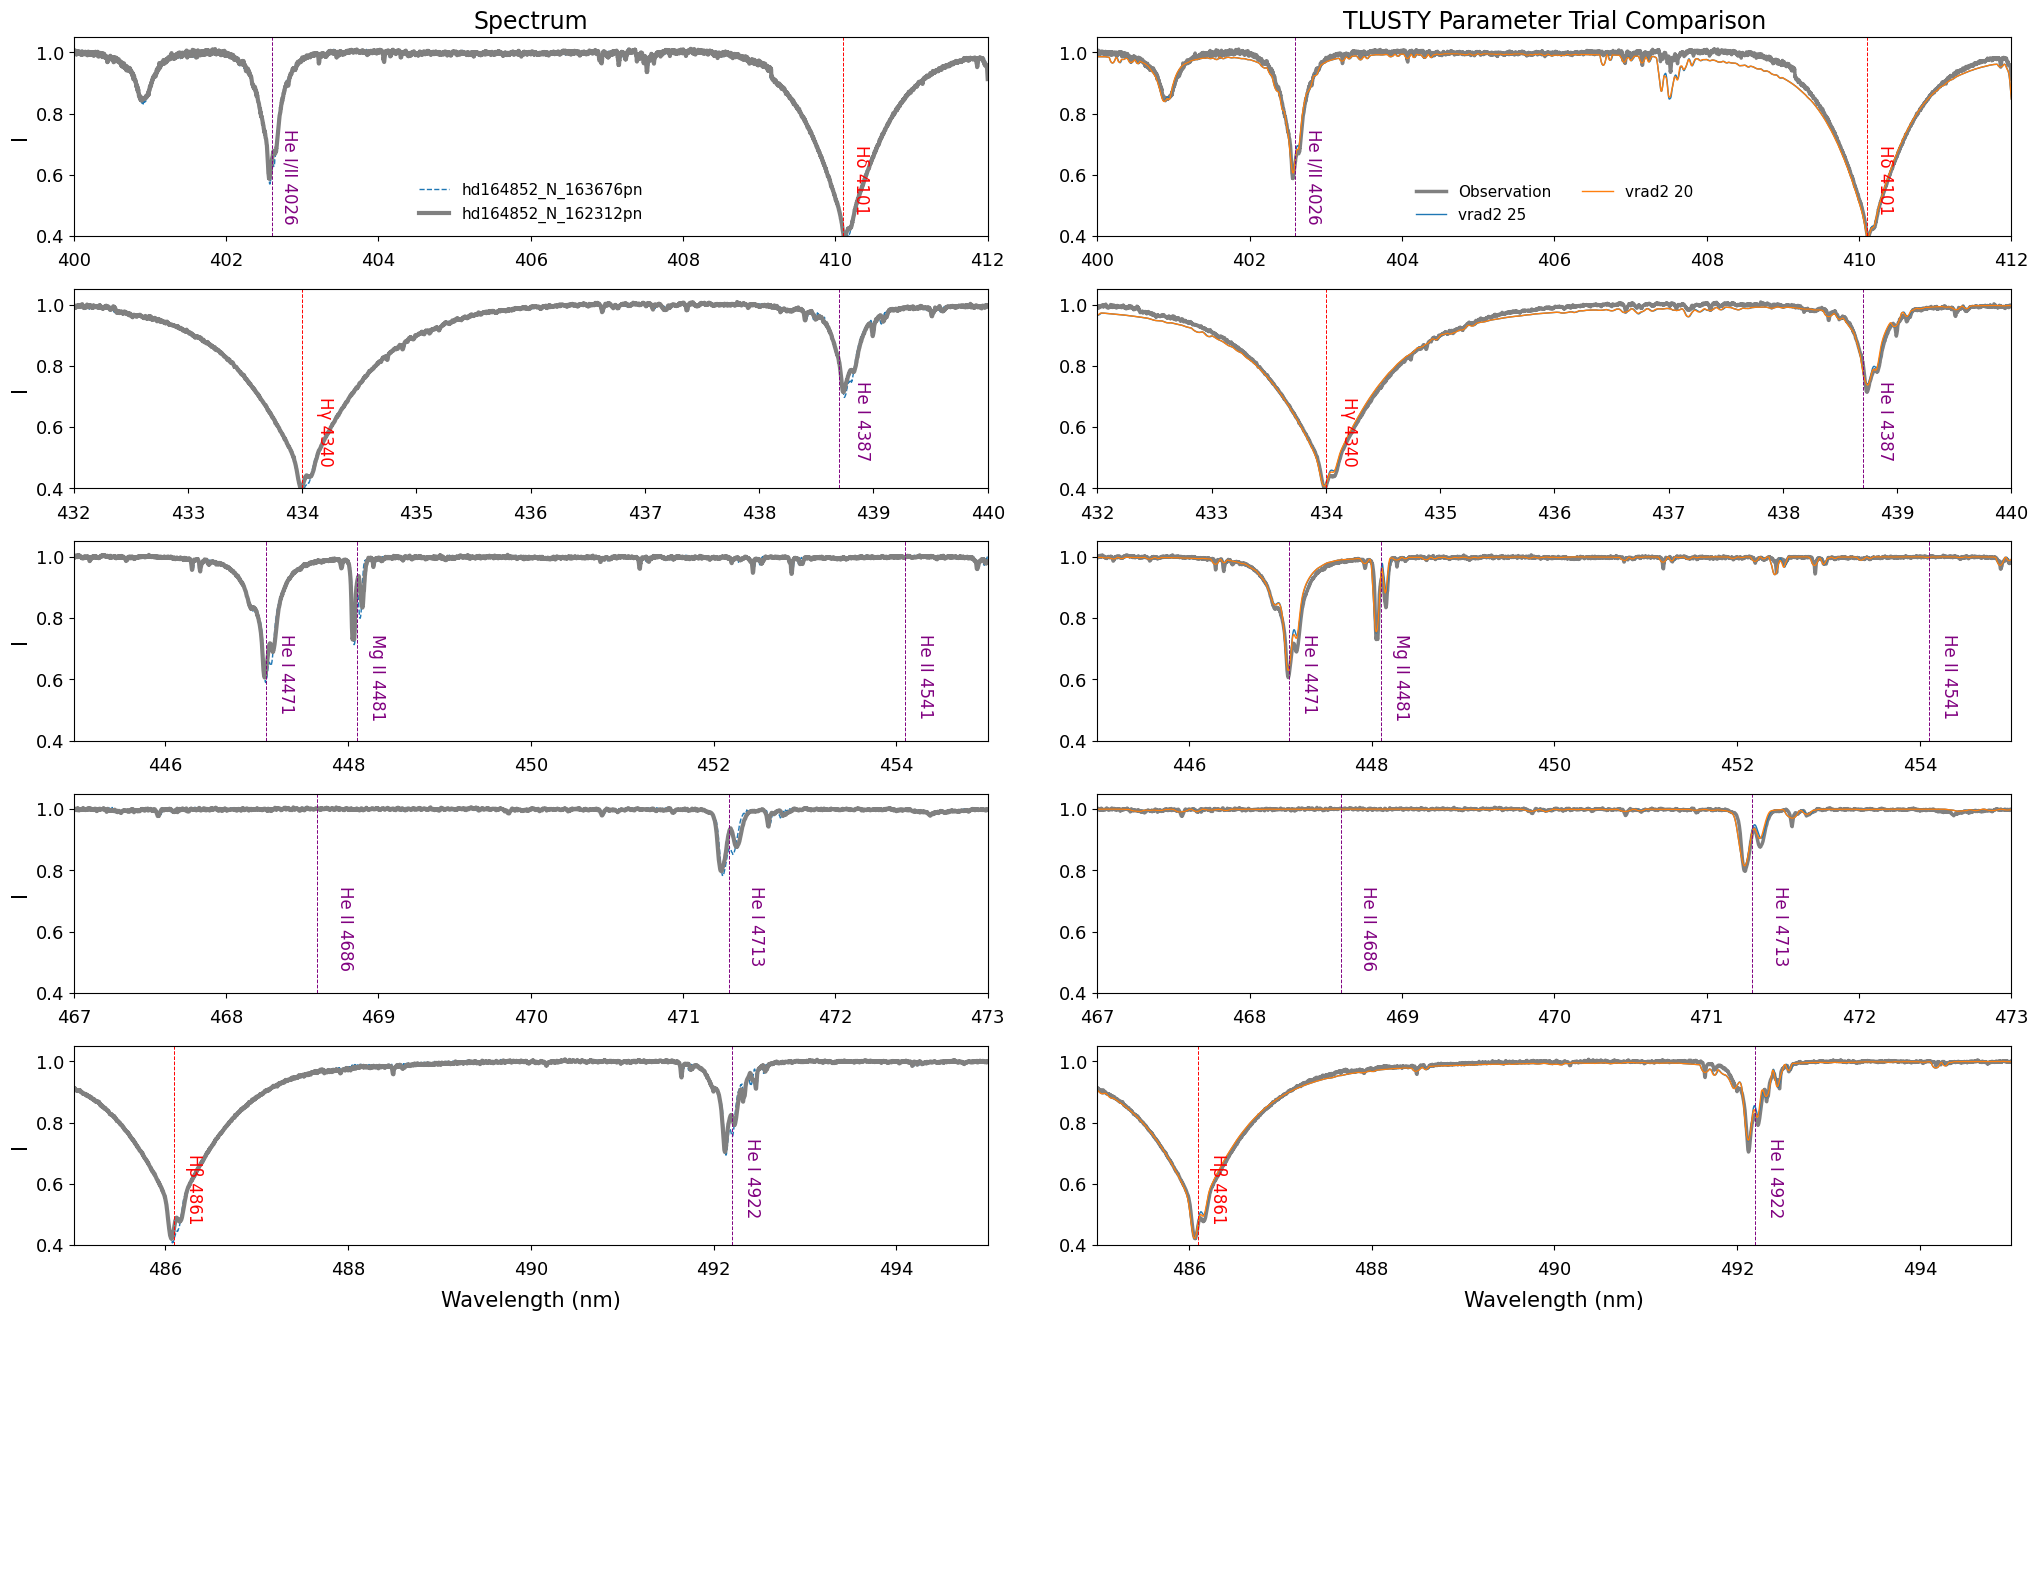

In [23]:
# =========================
# SIDE-BY-SIDE TRIAL COMPARISON
# =========================

y_lim = 0.4

fig = plt.figure(figsize=(25, 20))
gs = GridSpec(
    6, 2, figure=fig,
    height_ratios=[1, 1, 1, 1, 1, 1.4],
    hspace=0.25, wspace=0.12
)

ax_obs = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax_model = [fig.add_subplot(gs[i, 1]) for i in range(5)]
ax_text = fig.add_subplot(gs[5, :])

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
})

# ---------- LHS: all observations ----------
for i, (xmin, xmax) in enumerate(windows):
    a = ax_obs[i]

    for j, (spec_obs, label) in enumerate(zip(specs, labels)):
        if j != fit_index:
            a.plot(spec_obs.wl, spec_obs.specI, lw=1, ls="--", label=label)

    a.plot(spec.wl, spec.specI, lw=3, color="grey", label=labels[fit_index])
    a.set_xlim(xmin, xmax)
    a.set_ylim(y_lim, 1.05)
    a.set_ylabel("I")
    a.tick_params(axis="x", pad=8)

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl + 0.12, 0.7, label, color="red", fontsize=12,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl + 0.12, 0.75, label, color="purple", fontsize=12,
                   rotation=-90, ha="left", va="top")

ax_obs[0].legend(loc="lower center", frameon=False)
ax_obs[0].set_title("Spectrum")
ax_obs[-1].set_xlabel("Wavelength (nm)", labelpad=8)

# ---------- RHS: observation + every trial model ----------
for i, (xmin, xmax) in enumerate(windows):
    a = ax_model[i]
    a.plot(spec.wl, spec.specI, color="grey", lw=2.5, label="Observation")

    for name, params, model in models:
        a.plot(model.wl / 10, model.specI, lw=1, label=name)

    a.set_xlim(xmin, xmax)
    a.set_ylim(y_lim, 1.05)
    a.tick_params(axis="x", pad=8)

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl + 0.12, 0.7, label, color="red", fontsize=12,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl + 0.12, 0.75, label, color="purple", fontsize=12,
                   rotation=-90, ha="left", va="top")

ax_model[0].legend(loc="lower center", frameon=False, ncol=2)
ax_model[0].set_title("TLUSTY Parameter Trial Comparison")
ax_model[-1].set_xlabel("Wavelength (nm)", labelpad=8)

# ---------- Parameter summary ----------
ax_text.axis("off")
# ax_text.text(
#     0.01, 0.98, notes,
#     va="top", fontsize=11, wrap=True,
#     transform=ax_text.transAxes
# )

# comparison_pdf = save_folder / f"{observation_name.replace('_rn.s', '')}_parameter_trials.pdf"
# plt.savefig(comparison_pdf, dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()

# print(f"Saved comparison plot to: {comparison_pdf}")


In [ ]:
[x for x in dir(specs[1]) if "doppler" in x.lower()]# print(type(specs[1]))
# specs[1] = specs[1].doppler_shift(20)
# import inspect
# print(inspect.getfile(type(specs[1])))
# print(inspect.getsource(type(specs[1])))
print(pol.__version__)

1.1.0


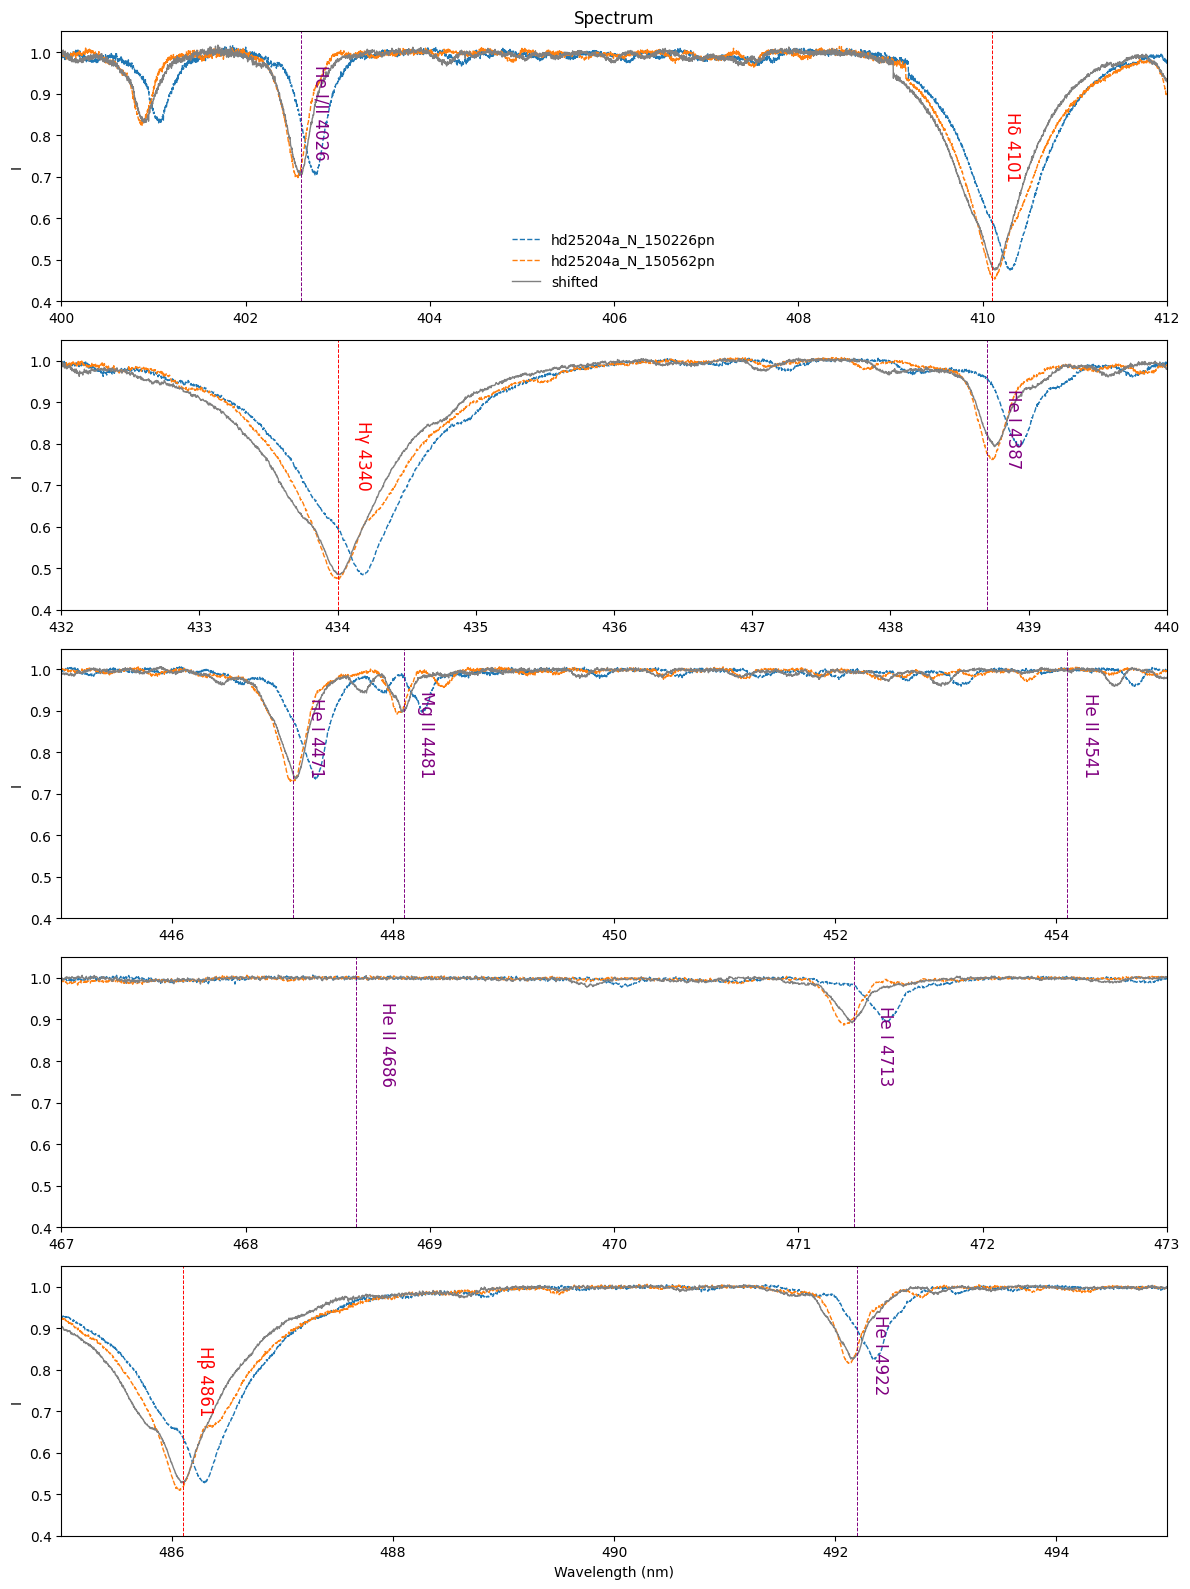

In [21]:
# doppler shift one of the spectra

spec1_shifted = specs[1].doppler_shift(-120)
fig, ax_obs = plt.subplots(5, 1, figsize=(12, 16))

for i, (xmin, xmax) in enumerate(windows):
    a = ax_obs[i]

    for j, (spec_obs, label) in enumerate(zip(specs, labels)):
        if j != fit_index:
            a.plot(spec_obs.wl, spec_obs.specI, lw=1, ls="--", label=label)
    a.plot(spec1_shifted.wl, spec1_shifted.specI, lw=1, color="grey", label="shifted")

    # a.plot(spec.wl, spec.specI, lw=3, color="grey", label=labels[fit_index])
    a.set(xlim=(xmin, xmax), ylim=(0.4, 1.05), ylabel="I")

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.7, label, color="red", fontsize=12, rotation=-90)

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.75, label, color="purple", fontsize=12, rotation=-90)

ax_obs[0].legend(loc="lower center", frameon=False)
ax_obs[0].set_title("Spectrum")
ax_obs[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()

In [24]:
# component_1, component_2, label_1, label_2 = make_binary_components(models[0])


name, params, model = models[0]

component_1, component_2, label_1, label_2 = make_binary_components(params)

save_binary_model(
    observation_name.replace("_rn.s", ""),
    params,
    component_1,
    component_2,
    model
)

Saved to G:\Shared drives\BinamicsOstars\TLUSTY Models\hd164852_N_162312pn
